In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from football_analytics.analyses.passing.features import passing_feature_columns
import os
os.environ["OMP_NUM_THREADS"] = "4"
from sklearn.preprocessing import StandardScaler


In [2]:
df_2018_wc = pd.read_parquet("../../../artifacts/features/player_level_wc2018.parquet")
df_2022_wc = pd.read_parquet("../../../artifacts/features/player_level_wc2022.parquet")
df_2024_euro = pd.read_parquet("../../../artifacts/features/player_level_euro2024.parquet")
df_2020_euro = pd.read_parquet("../../../artifacts/features/player_level_euro2020.parquet")
df_2023_afcon = pd.read_parquet("../../../artifacts/features/player_level_afcon2023.parquet")
df_2024_copa = pd.read_parquet("../../../artifacts/features/player_level_copa2024.parquet")

df_2018_wc["dataset"] = "WC2018"
df_2022_wc["dataset"] = "WC2022"
df_2024_euro["dataset"] = "EURO2024"
df_2020_euro["dataset"] = "EURO2020"
df_2023_afcon["dataset"] = "AFCON2023"
df_2024_copa["dataest"] = "COPA2024"

df = pd.concat([df_2018_wc, df_2022_wc, df_2024_euro, df_2020_euro, df_2024_copa, df_2023_afcon], ignore_index=True)
df = df[df["player_position"] != "Goalkeeper"]
passing_cols = passing_feature_columns()
passing_df = df[["player_key", "player_position", "player"] + passing_cols]
orig_df = df.copy()

df = passing_df.copy()
df = df.dropna(subset=["player_position"])

FEATURES = [
    'passes_per_90','short_passes_per_90','medium_passes_per_90','long_passes_per_90',
    'crosses_per90','switches_per90','throughballs_per90','cutbacks_per90','backheels_per90',
    'passes_under_pressure_per90','key_passes_per90','assists_per90','pct_passes_under_pressure',
    'avg_pass_length','std_pass_length','pct_short_pass','pct_med_pass','pct_long_pass',
    'pct_ground_pass','pct_low_pass','pct_high_pass','pct_left_foot_pass','pct_right_foot_pass',
    'pct_head_pass','pct_foot_pass','pct_other_pass','pct_keeper_arm_pass',
    'pct_progressive_passes','pct_lateral_passes','pct_defensive_passes',
    'pct_pass_from_def_third','pct_pass_from_mid_third','pct_pass_from_att_third',
    'pct_pass_from_left_channel','pct_pass_from_central_channel','pct_pass_from_right_channel',
    'pct_pass_to_def_third','pct_pass_to_mid_third','pct_pass_to_left_channel',
    'pct_pass_to_central_channel','pct_pass_to_right_channel',
    'pct_passes_final_third','pct_passes_into_box',
    'pct_pass_from_zone_dl','pct_pass_to_zone_dl','pct_pass_from_zone_dc','pct_pass_to_zone_dc',
    'pct_pass_from_zone_dr','pct_pass_to_zone_dr','pct_pass_from_zone_ml','pct_pass_to_zone_ml',
    'pct_pass_from_zone_mc','pct_pass_to_zone_mc','pct_pass_from_zone_mr','pct_pass_to_zone_mr',
    'pct_pass_from_zone_al','pct_pass_to_zone_al','pct_pass_from_zone_ac','pct_pass_to_zone_ac',
    'pct_pass_from_zone_ar','pct_pass_to_zone_ar',
    'pct_pass_def_to_mid','pct_pass_def_to_att','pct_pass_mid_to_att','pct_pass_mid_to_mid',
    'pct_pass_att_to_mid','pct_pass_def_to_def','pct_pass_att_to_att',
    'pct_pass_left_to_centre','pct_pass_left_to_right','pct_pass_right_to_centre',
    'pct_pass_right_to_left','pct_pass_centre_to_left','pct_pass_centre_to_right',
    'pct_pass_wide_to_box','pct_pass_centre_to_box','pct_pass_def_to_box',
    'ttl_passes_F','pct_passes_F','passes_F_per90',
    'ttl_passes_FR','pct_passes_FR','passes_FR_per90',
    'ttl_passes_R','pct_passes_R','passes_R_per90',
    'ttl_passes_BR','pct_passes_BR','passes_BR_per90',
    'ttl_passes_B','pct_passes_B','passes_B_per90',
    'ttl_passes_BL','pct_passes_BL','passes_BL_per90',
    'ttl_passes_L','pct_passes_L','passes_L_per90',
    'ttl_passes_FL','pct_passes_FL','passes_FL_per90',
    'pass_angle_mean_overall','pass_angle_var_overall',
    'pass_angle_mean_def_third','pass_angle_var_def_third',
    'pass_angle_mean_mid_third','pass_angle_var_mid_third',
    'pass_angle_mean_att_third','pass_angle_var_att_third',
    'pass_angle_mean_left_channel','pass_angle_var_left_channel',
    'pass_angle_mean_centre_channel','pass_angle_var_centre_channel',
    'pass_angle_mean_right_channel','pass_angle_var_right_channel'
]

df0 = passing_df.copy()

df1 = df0[
    (df0["has_minutes"] == 1) &
    (df0["has_pass_events"] == 1) &
    (df0["passes_per_90"].fillna(0) > 0) &
    (df0["player_position"].notna())
].copy()

In [3]:
len(df0), len(df1), df1["player_position"].value_counts().head(30)

(2938,
 2248,
 player_position
 Left Center Back             214
 Right Center Back            207
 Center Forward               184
 Right Back                   175
 Left Back                    167
 Left Wing                    144
 Right Wing                   140
 Right Defensive Midfield     123
 Left Defensive Midfield      115
 Right Center Midfield        112
 Left Center Midfield         105
 Center Attacking Midfield     86
 Center Defensive Midfield     78
 Right Wing Back               60
 Center Back                   52
 Right Center Forward          52
 Left Wing Back                51
 Left Midfield                 49
 Right Midfield                49
 Left Center Forward           48
 Right Attacking Midfield      19
 Left Attacking Midfield       15
 Center Midfield                3
 Name: count, dtype: int64)

In [4]:
df1 = df1[df1['player_position'] == 'Left Center Back']
df1

,player_key,player_position,player,has_pass_events,has_minutes,has_pass_lengths,has_pass_end_locations,has_pass_dx,has_pass_angles,has_pass_outcomes,...,pass_angle_mean_mid_third,pass_angle_var_mid_third,pass_angle_mean_att_third,pass_angle_var_att_third,pass_angle_mean_left_channel,pass_angle_var_left_channel,pass_angle_mean_centre_channel,pass_angle_var_centre_channel,pass_angle_mean_right_channel,pass_angle_var_right_channel
5,2999.0,Left Center Back,Presnel Kimpembe,1,1,1,1,1,1,1,...,30.111268,0.586630,16.568848,4.554567e-01,35.276266,0.639635,-3.403311,0.467946,49.398705,0.000000
7,3027.0,Left Center Back,Mathias Jattah-Njie Jørgensen,1,1,1,1,1,1,1,...,37.263353,0.509993,11.309932,1.110223e-16,53.212375,0.569341,16.290798,0.531110,52.573477,0.171075
15,3077.0,Left Center Back,Jan Vertonghen,1,1,1,1,1,1,1,...,63.839794,0.563554,64.013555,5.595923e-01,59.762324,0.509465,32.507242,0.603724,-67.619865,0.000000
23,3167.0,Left Center Back,Antonio Rüdiger,1,1,1,1,1,1,1,...,29.672492,0.700382,20.351055,9.242463e-01,48.953779,0.605498,22.699112,0.772258,52.864131,0.467423
55,3336.0,Left Center Back,Harry Maguire,1,1,1,1,1,1,1,...,41.161888,0.596557,-3.139586,7.289183e-01,49.706869,0.563966,4.805701,0.609440,-50.914718,0.734625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035,135004.0,Left Center Back,Lubeni Haukongo,1,1,1,1,1,1,1,...,37.044149,0.503853,0.000000,0.000000e+00,47.912685,0.514198,10.528397,0.612165,12.743457,0.871881
3068,160943.0,Left Center Back,Mohamed Amine Tougai,1,1,1,1,1,1,1,...,12.789894,0.655086,0.000000,0.000000e+00,43.862992,0.562406,-1.985045,0.610634,0.000000,0.000000
3087,264954.0,Left Center Back,Lamine Ba,1,1,1,1,1,1,1,...,24.666485,0.590866,74.919970,1.713818e-03,27.922979,0.574539,17.606879,0.599112,39.393297,0.068128
3089,270407.0,Left Center Back,Joaquim Marcos Cunga Balanga,1,1,1,1,1,1,1,...,66.924264,0.628729,117.957987,0.000000e+00,44.481731,0.680431,52.338434,0.497861,0.000000,0.000000


In [5]:


X = df1[FEATURES].copy()
X[FEATURES].isna().mean().sort_values(ascending=False).head(15)
X["backheels_per90"] = X["backheels_per90"].fillna(0.0)

df_model = X

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_model[FEATURES])
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES, index=df_model.index)
X_scaled.head(10)

C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\sklearn\preprocessing\_data.py:1656: RuntimeWarning: All-NaN slice encountered
  self.center_ = np.nanmedian(X, axis=0)
C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


,passes_per_90,short_passes_per_90,medium_passes_per_90,long_passes_per_90,crosses_per90,switches_per90,throughballs_per90,cutbacks_per90,backheels_per90,passes_under_pressure_per90,...,pass_angle_mean_mid_third,pass_angle_var_mid_third,pass_angle_mean_att_third,pass_angle_var_att_third,pass_angle_mean_left_channel,pass_angle_var_left_channel,pass_angle_mean_centre_channel,pass_angle_var_centre_channel,pass_angle_mean_right_channel,pass_angle_var_right_channel
5,1.143231,1.018476,0.733897,0.955945,0.000000,-0.225073,0.000000,0.0,0.0,0.803861,...,0.179012,0.122092,0.033689,0.020813,-0.018791,0.868802,-0.540339,-0.886410,1.257313,-0.652497
7,-0.286240,-0.374258,-0.436877,0.423465,0.000000,-0.335946,0.000000,0.0,0.0,0.240245,...,0.422487,-0.494053,-0.036978,-0.702803,0.680480,0.278627,0.038227,-0.438045,1.321769,-0.345171
15,0.377785,0.428661,0.219284,0.127924,3.530866,-0.004907,0.000000,0.0,0.0,2.947258,...,1.327215,-0.063433,0.671227,0.186261,0.935842,-0.224078,0.514627,0.077394,-1.118488,-0.652497
23,1.415214,0.815286,1.553673,0.344067,0.000000,1.759691,0.000000,0.0,0.0,-0.362480,...,0.164075,1.036639,0.084512,0.765612,0.514451,0.582198,0.226488,1.273703,1.327670,0.187197
55,0.653229,1.055611,0.357343,-0.150519,2.549882,0.632441,0.143541,0.0,0.0,2.597082,...,0.555203,0.201906,-0.231144,0.455281,0.543812,0.233504,-0.299178,0.117968,-0.779328,0.667209
68,-0.061786,-0.353190,-0.099775,0.453661,0.000000,0.027639,0.000000,0.0,0.0,0.230411,...,-0.294614,-0.323350,0.837917,-0.386087,-0.345804,-0.649120,-0.034398,-0.424706,-0.422756,0.296772
87,0.175991,0.906646,0.067771,-1.111636,1.407373,-0.925153,0.000000,0.0,0.0,0.999799,...,-0.002970,-0.034076,-0.341098,0.237073,-0.306249,0.260824,-0.322808,-1.027726,-0.208552,-0.313420
96,-0.205384,0.405747,-0.425459,-0.583448,0.000000,1.875168,0.000000,0.0,0.0,0.803861,...,0.080021,0.381697,0.691955,-0.702803,0.745230,-0.067035,-0.951123,-0.251907,-0.284962,-0.652497
111,-0.468966,-0.141315,-0.297735,-1.057269,0.000000,-0.606779,0.000000,0.0,0.0,-0.016070,...,0.890835,0.970299,0.422541,-0.272290,0.693830,-0.319791,0.756708,0.370717,-0.229225,0.954545
112,-0.238901,0.010931,-0.303026,-0.365267,1.049066,-0.412496,0.000000,0.0,0.0,0.742925,...,-0.493994,0.170967,-2.435635,0.716797,0.143642,-0.225937,-0.852252,0.235290,1.260583,0.503580


In [6]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_model[FEATURES])
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES, index=df_model.index)
X_scaled.head(10)

from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(
    X_pca,
    index=df_model.index,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

import numpy as np
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

threshold = 0.90  # For 90% explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= threshold) + 1

print(f"Number of components that explain {threshold*100}% variance: {n_components}")

C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\sklearn\preprocessing\_data.py:1656: RuntimeWarning: All-NaN slice encountered
  self.center_ = np.nanmedian(X, axis=0)
C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [12]:
pca = PCA(n_components=24)
X_pca=pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(
    X_pca,
    index=df_model.index,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)


C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib

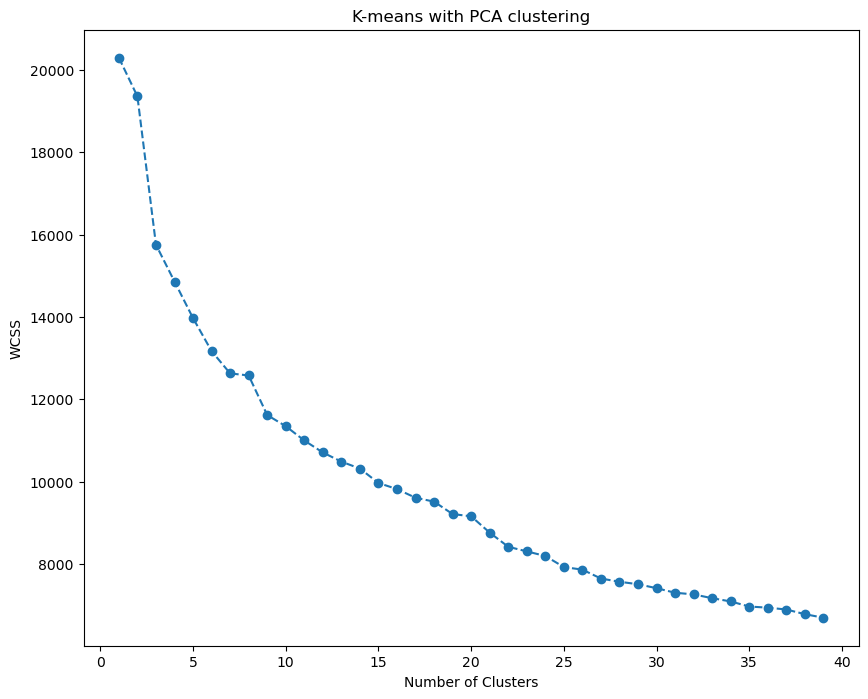

In [13]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1,40):
    kmeans_pca = KMeans(n_clusters = i, init = "k-means++", random_state = 42)
    kmeans_pca.fit(X_pca)
    wcss.append(kmeans_pca.inertia_)

plt.figure(figsize = (10,8))
plt.plot(range(1,40), wcss, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means with PCA clustering')
plt.show()

In [14]:
kmeans = KMeans(n_clusters=8, random_state=42)
df_model["role_id"] = kmeans.fit_predict(X_pca.iloc[:, :30])
df_model["role_id"].value_counts()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(df_model[FEATURES]),
    columns=FEATURES,
    index=df_model.index
)

X_std["role_id"] = df_model["role_id"]
X_std.sample(10)

role_profiles = X_std.groupby("role_id")[FEATURES].mean()
for r in role_profiles.index:
    print(f"\nROLE {r}")
    print("Top + traits")
    print(role_profiles.loc[r].sort_values(ascending=False).head(10))
    print("\nTop - traits")
    print(role_profiles.loc[r].sort_values().head(10))


ROLE 0
Top + traits
pct_pass_from_zone_ml         1.071602
pct_pass_from_left_channel    0.973868
pct_pass_to_zone_al           0.929802
pct_pass_from_zone_al         0.855579
pct_pass_from_att_third       0.853297
pct_pass_att_to_att           0.847025
pct_passes_final_third        0.770507
pct_pass_left_to_centre       0.711799
pass_angle_mean_overall       0.691351
pass_angle_mean_mid_third     0.664056
Name: 0, dtype: float64

Top - traits
pct_pass_from_central_channel   -0.933189
pct_pass_centre_to_left         -0.928750
pct_pass_to_right_channel       -0.845431
pct_pass_from_zone_dc           -0.842277
pct_passes_L                    -0.795762
pct_pass_centre_to_right        -0.789411
pct_pass_from_zone_mc           -0.751857
pct_pass_to_zone_mr             -0.744125
pct_pass_to_zone_dr             -0.737362
pct_pass_from_def_third         -0.696818
Name: 0, dtype: float64

ROLE 1
Top + traits
pct_passes_BL             3.606336
pct_head_pass             3.241004
backheels_per90 

C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
